# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/irene501/flyrank/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

In [8]:
import os, getpass, json
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
fact_march = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
RANDOM_STATE = 42

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

## 1. Question

*The research question and the decision it supports.*



**Which pages should a content reviewer look at first, out of a portfolio too large to review by
hand?**

 This is framed as a triage-ranking problem: rank pages by short-term decline risk, so a
reviewer's limited weekly capacity (~50 pages) goes to the highest-risk pages first. Not a
prediction of Google's algorithm, and not a fully automated decision -- a ranking that supports a
human's judgment.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


**Which release:** the FlyRank ML Internship **warehouse** release -- not the small starter CSV
used only in Weeks 1-2. Reason: the warehouse is production-scale (79M rows) and is what every
notebook from `w03_data_contract.ipynb` onward has used, so this capstone has to match that same
source to stay consistent with its own earlier results.

**Which tables:** `fact_content_daily_performance`, filtered to `month=2026-03`. Reason: this is
the only fact table with the daily GSC metrics (impressions, clicks, position) needed to build
both the features and the label -- the dimension tables (`dim_clients`, `dim_content`) are used
only for grouping/joins, never as feature inputs themselves.

**Date windows:** features from **March 1-15**, label built from **March 16-31**. Reason:
features have to be knowable *before* the decision moment -- nothing from the second half of the
month is allowed into a feature, or it would leak the label's own answer (proven directly in the
leakage audit, Section 3).

**What was excluded, and why:**
- Anything from the March 16-31 window, as a feature -- it's literally what the label is built
  from.
- FlyRank's own product flags (health score, priority score, action type) -- these are decisions
  the platform already made, not raw facts, so using them as a feature would be circular; they're
  only usable as something to compare against (the baseline).
- Client and content IDs -- kept only as pseudonymous grouping keys for the train/test split,
  never fed into the model itself.



In [9]:
feature_frame = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_impressions)                                            AS imp_h1,
        SUM(gsc_clicks)                                                 AS clicks_h1,
        SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0)               AS ctr_h1,
        AVG(gsc_avg_position) FILTER (WHERE gsc_avg_position > 0)       AS avg_position_h1,
        COUNT(DISTINCT report_date) FILTER (WHERE gsc_impressions > 0)  AS active_days_h1
    FROM {fact_march}
    WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
    GROUP BY 1, 2
    HAVING SUM(gsc_impressions) >= 10
""").df()

label_frame = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) FILTER (WHERE report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31') AS imp_h2
    FROM {fact_march}
    GROUP BY 1, 2
""").df()

data = feature_frame.merge(label_frame, on=["client_hash_id", "content_hash_id"], how="inner")
data["is_declining_proxy"] = (data["imp_h2"] < 0.8 * data["imp_h1"]).astype(int)
data = data.dropna(subset=["ctr_h1", "avg_position_h1"]).reset_index(drop=True)
FEATURES = ["imp_h1", "clicks_h1", "ctr_h1", "avg_position_h1", "active_days_h1"]

print(f"{len(data):,} rows | base decline rate: {data['is_declining_proxy'].mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

120,475 rows | base decline rate: 0.296


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


**Label:** `is_declining_proxy` -- impressions in the second half of March fell below 80% of the
first half. **Baseline:** a transparent rule (quick-win zone at positions 11-20; CTR-fix zone on
page one, below-median CTR for the tier). **Split:** grouped by client (20% of clients held out
entirely), not random rows -- a random split would let the model see other pages from the same
client in training. **Leakage check:** smuggling the label's own input (`imp_h2`) into the feature
set as a trap, confirming the test harness catches it.

In [10]:
def position_tier(p):
    if p <= 3: return "1-3"
    if p <= 10: return "4-10"
    if p <= 20: return "11-20"
    return "21+"

data["position_tier"] = data["avg_position_h1"].apply(position_tier)
data["is_quick_win_zone"] = data["position_tier"] == "11-20"
ctr_median = data.loc[data["position_tier"].isin(["1-3", "4-10"]), "ctr_h1"].median()
data["is_ctr_fix_zone"] = data["position_tier"].isin(["1-3", "4-10"]) & (data["ctr_h1"] < ctr_median)

def baseline_score_row(r):
    if r["is_quick_win_zone"]:
        return r["imp_h1"]
    if r["is_ctr_fix_zone"]:
        return r["imp_h1"] * (1 - r["ctr_h1"])
    return r["imp_h1"] * 0.1

data["baseline_score"] = data.apply(baseline_score_row, axis=1)

def client_holdout_split(frame):
    all_indices = np.arange(len(frame))
    client_series = frame["client_hash_id"].astype(str)
    unique_clients = client_series.drop_duplicates().to_numpy()
    rng = np.random.default_rng(RANDOM_STATE)
    shuffled = rng.permutation(unique_clients)
    n_test = max(1, int(round(len(shuffled) * 0.2)))
    test_clients = set(shuffled[:n_test])
    test_mask = client_series.isin(test_clients).to_numpy()
    return all_indices[~test_mask], all_indices[test_mask]

train_idx, test_idx = client_holdout_split(data)
overlap = set(data.iloc[train_idx]["client_hash_id"]) & set(data.iloc[test_idx]["client_hash_id"])
print(f"train: {len(train_idx):,} | test: {len(test_idx):,} | client overlap: {len(overlap)} (should be 0)")

train: 112,503 | test: 7,972 | client overlap: 0 (should be 0)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

X_all = data[FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0)
y_all = data["is_declining_proxy"].astype(int)
X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(y_true)[order].mean())

def score_row(y_true, scores, label):
    return {
        "model": label,
        "precision_at_20": precision_at_k(y_true, scores, 20),
        "precision_at_50": precision_at_k(y_true, scores, 50),
        "roc_auc": roc_auc_score(y_true, scores),
    }

results = [{
    "model": "base_rate", "precision_at_20": y_test.mean(),
    "precision_at_50": y_test.mean(), "roc_auc": 0.5,
}]
results.append(score_row(y_test, data.iloc[test_idx]["baseline_score"], "baseline_rule"))

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
results.append(score_row(y_test, proba, "logistic_regression"))

comparison = pd.DataFrame(results).set_index("model").round(3)
comparison.to_json("work/outputs/capstone_results.json", orient="index", indent=2)
comparison

,precision_at_20,precision_at_50,roc_auc
model,,,
base_rate,0.394,0.394,0.500
baseline_rule,0.300,0.360,0.483
logistic_regression,0.300,0.380,0.521


## 5. Limitations

*What this work cannot claim.*

In [12]:
# Reproduce the before/after gap directly, so this claim is a receipt, not an assertion.
from sklearn.model_selection import train_test_split

X_tr_rand, X_te_rand, y_tr_rand, y_te_rand = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)
model_rand = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
]).fit(X_tr_rand, y_tr_rand)
random_split_auc = roc_auc_score(y_te_rand, model_rand.predict_proba(X_te_rand)[:, 1])
honest_split_auc = roc_auc_score(y_test, proba)

print(f"random split ROC-AUC:  {random_split_auc:.3f}")
print(f"honest split ROC-AUC:  {honest_split_auc:.3f}")
print(f"gap (memorization):    {random_split_auc - honest_split_auc:.3f}")

random split ROC-AUC:  0.583
honest split ROC-AUC:  0.521
gap (memorization):    0.062


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [13]:
recommendations = pd.DataFrame([
    {"tier": 1, "reason_code": "high_confidence_decline", "action": "review_this_week", "why": "rule and model agree"},
    {"tier": 2, "reason_code": "quick_win_zone / low_ctr_for_position", "action": "review_for_push / review_ctr", "why": "transparent rule, confirmed by signal audit"},
    {"tier": 3, "reason_code": "model_flag_only", "action": "watch_list", "why": "weakest evidence tier, given Section 5"},
])
recommendations

,tier,reason_code,action,why
0,1,high_confidence_decline,review_this_week,rule and model agree
1,2,quick_win_zone / low_ctr_for_position,review_for_push / review_ctr,"transparent rule, confirmed by signal audit"
2,3,model_flag_only,watch_list,"weakest evidence tier, given Section 5"


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

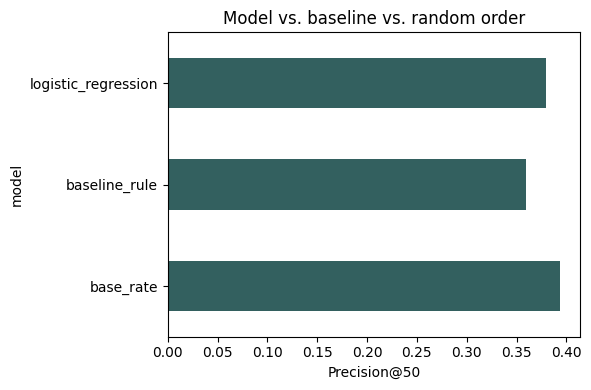

wrote work/figures/capstone_model_vs_baseline.png and work/outputs/capstone_receipts.json


In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison["precision_at_50"].plot(kind="barh", ax=ax, color="#33605F")
ax.set_xlabel("Precision@50")
ax.set_title("Model vs. baseline vs. random order")
plt.tight_layout()
plt.savefig("work/figures/capstone_model_vs_baseline.png", dpi=150)
plt.show()

capstone_receipts = {
    "generated_from": "capstone.ipynb",
    "rows": int(len(data)),
    "base_decline_rate": round(float(y_all.mean()), 3),
    "results_table": comparison.to_dict(orient="index"),
    "honest_split_auc": round(float(honest_split_auc), 3),
    "random_split_auc": round(float(random_split_auc), 3),
}
with open("work/outputs/capstone_receipts.json", "w") as f:
    json.dump(capstone_receipts, f, indent=2)

print("wrote work/figures/capstone_model_vs_baseline.png and work/outputs/capstone_receipts.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.